User posting behaviour with https://bsky-data.leobalduf.com/posts.parquet. 



In [ ]:
# Imports and setup
import fsspec
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_election import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


## Remote Schema expolaration
1) The *user posts* database is 44GB big. 
2) The *profiles posts* database is 1.8GB big. 

In [ ]:
from datetime import datetime

POSTS_URL = "https://bsky-data.leobalduf.com/posts.parquet"

# First, just understand the structure
with fsspec.open(POSTS_URL, "rb") as f:
    parquet_file = pq.ParquetFile(f)
    print("Posts Database")
    print("Columns:", parquet_file.schema.names)
    print("Number of rows:", parquet_file.metadata.num_rows)
    print("Number of row groups:", parquet_file.metadata.num_row_groups)
    
def analyze_temporal_data_safe():
    """Analyze temporal data with error handling for HTTP sources"""
    with fsspec.open(POSTS_URL, "rb") as f:
        parquet_file = pq.ParquetFile(f)
        
        print("=== Dataset Structure ===")
        print(f"Total rows: {parquet_file.metadata.num_rows:,}")
        print(f"Row groups: {parquet_file.num_row_groups}")
        
        # Read first row group to understand data structure
        print("\n=== First Row Group Analysis ===")
        first_group = parquet_file.read_row_group(0).to_pandas()
        print(f"First group size: {len(first_group):,} rows")
        
        # Check created_at column
        created_at_sample = first_group['created_at'].head()
        print(f"\nSample created_at values: {created_at_sample.tolist()}")
        print(f"Data type: {first_group['created_at'].dtype}")
        
        # Convert to datetime if needed
        if first_group['created_at'].dtype in ['object', 'string']:
            first_group['created_at'] = pd.to_datetime(first_group['created_at'])
        elif first_group['created_at'].dtype in ['int64', 'int32', 'float64']:
            # Likely Unix timestamp
            first_group['created_at'] = pd.to_datetime(first_group['created_at'], unit='s')
        
        print(f"After conversion - min: {first_group['created_at'].min()}")
        print(f"After conversion - max: {first_group['created_at'].max()}")
        
        return first_group, parquet_file

def check_temporal_sorting(parquet_file, num_samples=5):
    """Check if data is sorted by sampling multiple row groups"""
    print(f"\n=== Checking Temporal Sorting ({num_samples} samples) ===")
    
    timestamps_info = []
    
    # Sample row groups from different parts of the dataset
    sample_indices = [
        0, 
        parquet_file.num_row_groups // 4,
        parquet_file.num_row_groups // 2,
        parquet_file.num_row_groups * 3 // 4,
        parquet_file.num_row_groups - 1
    ]
    
    for i, group_idx in enumerate(sample_indices[:num_samples]):
        try:
            group_data = parquet_file.read_row_group(group_idx).to_pandas()
            
            # Handle timestamp conversion
            if group_data['created_at'].dtype in ['object', 'string']:
                group_data['created_at'] = pd.to_datetime(group_data['created_at'])
            elif group_data['created_at'].dtype in ['int64', 'int32', 'float64']:
                group_data['created_at'] = pd.to_datetime(group_data['created_at'], unit='s')
            
            group_min = group_data['created_at'].min()
            group_max = group_data['created_at'].max()
            
            timestamps_info.append({
                'group': group_idx,
                'min_date': group_min,
                'max_date': group_max,
                'rows': len(group_data)
            })
            
            print(f"Group {group_idx:4d}: {group_min} to {group_max} ({len(group_data):,} rows)")
            
        except Exception as e:
            print(f"Error reading group {group_idx}: {e}")
    
    return timestamps_info

def analyze_time_range(timestamps_info):
    """Analyze the overall time range from sampled groups"""
    print("\n=== Time Range Analysis ===")
    
    if not timestamps_info:
        print("No timestamp data available")
        return
    
    all_mins = [info['min_date'] for info in timestamps_info]
    all_maxs = [info['max_date'] for info in timestamps_info]
    
    overall_min = min(all_mins)
    overall_max = max(all_maxs)
    
    print(f"Earliest timestamp in samples: {overall_min}")
    print(f"Latest timestamp in samples: {overall_max}")
    print(f"Total time span: {overall_max - overall_min}")
    print(f"Approximate days: {(overall_max - overall_min).days} days")
    
    # Check if sorted
    mins_sorted = all_mins == sorted(all_mins)
    maxs_sorted = all_maxs == sorted(all_maxs)
    
    print(f"\nSorting analysis:")
    print(f"Minimum dates sorted: {mins_sorted}")
    print(f"Maximum dates sorted: {maxs_sorted}")
    print(f"Likely chronologically sorted: {mins_sorted and maxs_sorted}")

def sample_temporal_distribution(parquet_file, sample_size=10000):
    """Sample posts to understand temporal distribution"""
    print(f"\n=== Temporal Distribution Sampling ===")
    
    all_timestamps = []
    
    # Sample from multiple row groups
    groups_to_sample = min(10, parquet_file.num_row_groups)
    posts_per_group = sample_size // groups_to_sample
    
    for i in range(0, parquet_file.num_row_groups, max(1, parquet_file.num_row_groups // groups_to_sample)):
        try:
            group_data = parquet_file.read_row_group(i).to_pandas()
            
            # Convert timestamps
            if group_data['created_at'].dtype in ['object', 'string']:
                group_data['created_at'] = pd.to_datetime(group_data['created_at'])
            elif group_data['created_at'].dtype in ['int64', 'int32', 'float64']:
                group_data['created_at'] = pd.to_datetime(group_data['created_at'], unit='s')
            
            # Sample from this group
            sample = group_data['created_at'].sample(min(posts_per_group, len(group_data)))
            all_timestamps.extend(sample.tolist())
            
        except Exception as e:
            continue
    
    if all_timestamps:
        df_times = pd.Series(all_timestamps)
        print(f"Sampled {len(df_times):,} posts")
        print(f"Date range in sample: {df_times.min()} to {df_times.max()}")
        
        # Basic temporal statistics
        print(f"\nTemporal distribution:")
        print(f"Median date: {df_times.median()}")
        print(f"Most common date: {df_times.dt.date.mode().iloc[0]}")
        
        # Distribution by year-month
        year_month_counts = df_times.dt.to_period('M').value_counts().sort_index()
        print(f"\nPosts by month (top 5):")
        print(year_month_counts.head())
        
    return all_timestamps

# Run the analysis
try:
    # First, understand the data structure
    first_group, parquet_file = analyze_temporal_data_safe()
    
    # Check temporal sorting
    timestamps_info = check_temporal_sorting(parquet_file, num_samples=5)
    
    # Analyze time range
    analyze_time_range(timestamps_info)
    
    # Sample for distribution analysis
    sampled_times = sample_temporal_distribution(parquet_file, sample_size=5000)
    
except Exception as e:
    print(f"Error in analysis: {e}")
    import traceback
    traceback.print_exc()


=== Efficient Range Analysis ===


ArrowInvalid: Unrecognized filesystem type in URI: https://bsky-data.leobalduf.com/posts.parquet

In [ ]:

PROFILES_URL = "https://bsky-data.leobalduf.com/profiles.parquet"

# First, just understand the structure
with fsspec.open(PROFILES_URL, "rb") as f:
    parquet_file = pq.ParquetFile(f)
    print("Profiles Database")
    print("Columns:", parquet_file.schema.names)
    print("Number of rows:", parquet_file.metadata.num_rows)
    print("Number of row groups:", parquet_file.metadata.num_row_groups)

In [31]:
def row_group_sampling(posts_url, profiles_url, user_sample_size=1000):
    """Most efficient - work with row groups"""
    
    # Sample from first few row groups of posts
    with fsspec.open(posts_url, "rb") as f:
        parquet_file = pq.ParquetFile(f)
        
        sampled_posts = []
        sampled_users = set()
        
        for i in range(min(5, parquet_file.metadata.num_row_groups)):
            print(f"Reading posts row group {i}...")
            # CORRECTED: Use the parquet_file object to read row groups
            posts_chunk = parquet_file.read_row_group(
                i, 
                columns=['did_id', 'created_at']
            ).to_pandas()
            
            sampled_posts.append(posts_chunk)
            current_users = pd.concat(sampled_posts)['did_id'].unique()
            
            if len(current_users) >= user_sample_size:
                sampled_users = set(current_users[:user_sample_size])
                break
    
    # Filter posts to only our sampled users
    all_posts = pd.concat(sampled_posts)
    filtered_posts = all_posts[all_posts['did_id'].isin(sampled_users)]
    
    # Get profiles for these users
    print("Loading profiles for sampled users...")
    with fsspec.open(profiles_url, "rb") as f:
        profiles_file = pq.ParquetFile(f)
        profiles_data = []
        
        # Read profiles in chunks too
        for i in range(min(5, profiles_file.metadata.num_row_groups)):  # Limit row groups
            profiles_chunk = profiles_file.read_row_group(
                i, 
                columns=['did_id', 'created_at']
            ).to_pandas()
            
            # Filter to only our sampled users
            profiles_chunk = profiles_chunk[profiles_chunk['did_id'].isin(sampled_users)]
            profiles_data.append(profiles_chunk)
            
            # Stop if we found profiles for all users
            found_users = pd.concat(profiles_data)['did_id'].nunique()
            print(f"Found profiles for {found_users}/{len(sampled_users)} users")
            if found_users >= len(sampled_users):
                break
    
    profiles_sample = pd.concat(profiles_data)
    
    return filtered_posts, profiles_sample

In [32]:
# This gets you 1000 users and their posts efficiently
posts_sample, profiles_sample = row_group_sampling(
    posts_url=POSTS_URL,
    profiles_url=PROFILES_URL, 
    user_sample_size=1000
)

print(f"Sampled {len(posts_sample)} posts from {posts_sample['did_id'].nunique()} users")
print(f"Found {len(profiles_sample)} profile records")

Reading posts row group 0...
Loading profiles for sampled users...
Found profiles for 4/1000 users
Found profiles for 10/1000 users
Found profiles for 12/1000 users
Found profiles for 16/1000 users
Found profiles for 19/1000 users
Sampled 35106 posts from 1000 users
Found 19 profile records


# Minimal User Frequency Prediciton

Let's start super simple with just 2-3 basic features. 

In [11]:
# Data sampling function (Get posts from 2000 users) 
def get_minimal_user_sample(url, user_sample_size=2000):
    """Get minimal user data with just basic features"""
    
    minimal_columns = ['did_id', 'created_at']
    
    print("Sampling minimal user data...")
    
    user_data = []
    with fsspec.open(url, "rb") as f:
        parquet_file = pq.ParquetFile(f)
        
        # Just use first 2 row groups to keep it simple
        for i in range(min(2, parquet_file.metadata.num_row_groups)):
            print(f"Reading row group {i+1}...")
            table = parquet_file.read_row_group(i, columns=minimal_columns)
            chunk_df = table.to_pandas()
            user_data.append(chunk_df)
            
            # Check if we have enough users
            current_users = pd.concat(user_data, ignore_index=True)['did_id'].nunique()
            if current_users >= user_sample_size:
                print(f"Reached target of {user_sample_size} users")
                break
    
    all_posts = pd.concat(user_data, ignore_index=True)
    print(f"Sampled {len(all_posts)} posts from {all_posts['did_id'].nunique()} users")
    return all_posts

In [12]:
# Cell 4: Sample the data
print("Starting data sampling...")
user_posts = get_minimal_user_sample(URL, USER_SAMPLE_SIZE)

print("\nSample of raw posts data:")
print(user_posts.head())
print(f"\nData types:")
print(user_posts.dtypes)

Starting data sampling...
Sampling minimal user data...
Reading row group 1...
Reached target of 2000 users
Sampled 123510 posts from 2531 users

Sample of raw posts data:
     did_id                       created_at
0  31955122 2023-09-16 19:36:58.558000+00:00
1  31955122 2024-11-15 16:22:35.542000+00:00
2  31955122 2024-11-16 21:00:29.703000+00:00
3  31955122 2024-11-22 20:30:39.146000+00:00
4  31955122 2024-12-13 18:34:28.434000+00:00

Data types:
did_id                      int64
created_at    datetime64[us, UTC]
dtype: object


In [13]:
# Cell 5: Feature engineering function
def create_simple_features(posts_df):
    """Create just 2-3 basic features for starter ML"""
    
    print("Creating simple features...")
    
    # Convert dates
    posts_df['created_at'] = pd.to_datetime(posts_df['created_at'])
    
    # Group by user - only calculate essential metrics
    user_features = posts_df.groupby('did_id').agg({
        'created_at': [
            ('total_posts', 'count'),
            ('first_post', 'min'),
            ('last_post', 'max')
        ]
    }).round(2)
    
    # Flatten columns
    user_features.columns = ['total_posts', 'first_post', 'last_post']
    user_features = user_features.reset_index()
    
    # Calculate just 2 simple features
    user_features['account_age_days'] = (
        user_features['last_post'] - user_features['first_post']
    ).dt.total_seconds() / (24 * 3600)
    
    user_features['account_age_days'] = user_features['account_age_days'].clip(lower=1)
    
    # Feature 3: Posts per day (simple ratio)
    user_features['posts_per_day'] = user_features['total_posts'] / user_features['account_age_days']
    
    # Simple binary target: Is this an "active" user?
    median_activity = user_features['posts_per_day'].median()
    user_features['is_active'] = (user_features['posts_per_day'] > median_activity).astype(int)
    
    # Keep only the essential columns
    simple_features = user_features[[
        'did_id', 'total_posts', 'account_age_days', 'posts_per_day', 'is_active'
    ]]
    
    print(f"Created features for {len(simple_features)} users")
    print(f"Active users: {simple_features['is_active'].sum()} ({simple_features['is_active'].mean()*100:.1f}%)")
    
    return simple_features

In [14]:
# Cell 6: Create features
print("Creating user features...")
user_features = create_simple_features(user_posts)

print("\nFeature summary:")
print(user_features.describe())

print("\nFirst few users with features:")
print(user_features.head(10))

Creating user features...
Creating simple features...
Created features for 2531 users
Active users: 1265 (50.0%)

Feature summary:
             did_id   total_posts  account_age_days  posts_per_day  \
count  2.531000e+03   2531.000000       2531.000000    2531.000000   
mean   1.697082e+07     48.798894         89.801706       0.985629   
std    9.939725e+06    563.332401        151.903974       2.311572   
min    7.776000e+03      1.000000          1.000000       0.003307   
25%    8.266478e+06      1.000000          1.000000       0.124087   
50%    1.670273e+07      4.000000         21.306950       0.615920   
75%    2.555275e+07     15.000000        111.543547       1.000000   
max    3.425173e+07  26086.000000        782.656498      66.794736   

         is_active  
count  2531.000000  
mean      0.499802  
std       0.500099  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       1.000000  
max       1.000000  

First few users with features:
   did_id  total_

Basic EDA...


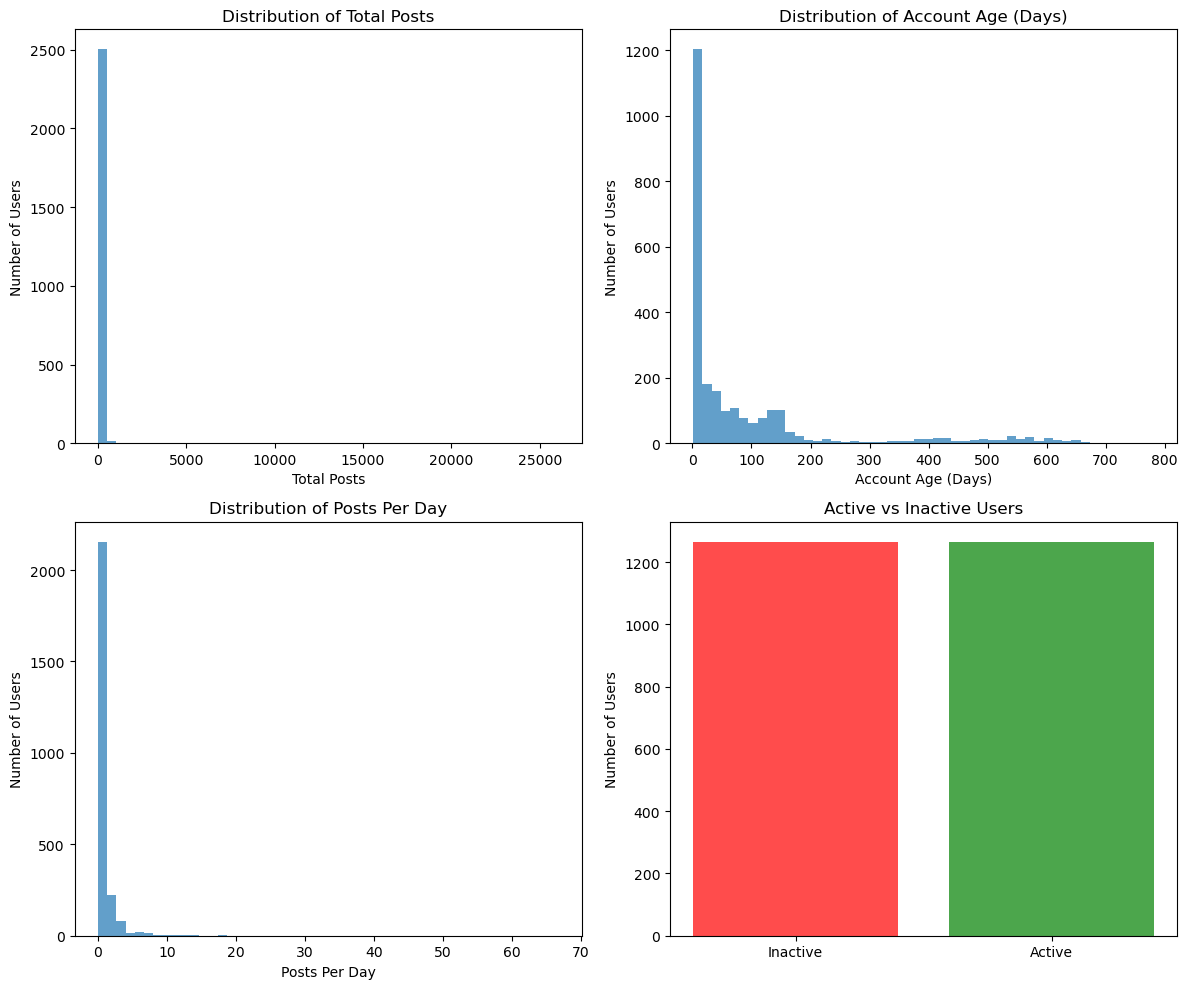

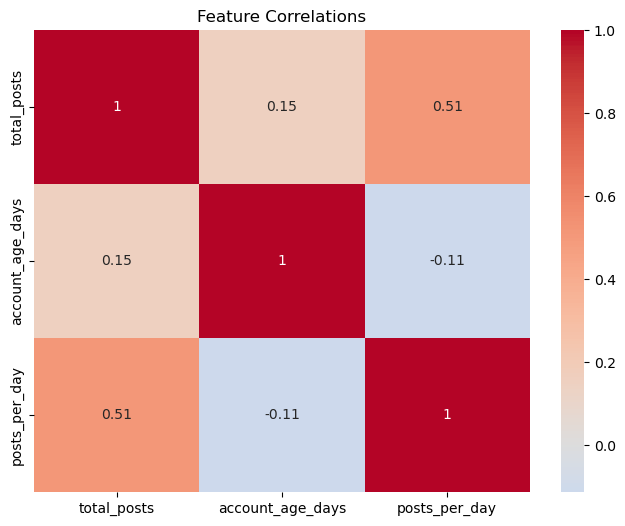

In [15]:
# Cell 7: Exploratory Data Analysis
print("Basic EDA...")

# Plot distribution of key features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Total posts distribution
axes[0, 0].hist(user_features['total_posts'], bins=50, alpha=0.7)
axes[0, 0].set_title('Distribution of Total Posts')
axes[0, 0].set_xlabel('Total Posts')
axes[0, 0].set_ylabel('Number of Users')

# Plot 2: Account age distribution
axes[0, 1].hist(user_features['account_age_days'], bins=50, alpha=0.7)
axes[0, 1].set_title('Distribution of Account Age (Days)')
axes[0, 1].set_xlabel('Account Age (Days)')
axes[0, 1].set_ylabel('Number of Users')

# Plot 3: Posts per day distribution
axes[1, 0].hist(user_features['posts_per_day'], bins=50, alpha=0.7)
axes[1, 0].set_title('Distribution of Posts Per Day')
axes[1, 0].set_xlabel('Posts Per Day')
axes[1, 0].set_ylabel('Number of Users')

# Plot 4: Active vs Inactive users
active_counts = user_features['is_active'].value_counts()
axes[1, 1].bar(['Inactive', 'Active'], active_counts.values, color=['red', 'green'], alpha=0.7)
axes[1, 1].set_title('Active vs Inactive Users')
axes[1, 1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_cols = user_features[['total_posts', 'account_age_days', 'posts_per_day']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlations')
plt.show()

# Model Training

Do not run this if you don't have any correlation.

In [16]:
# Cell 8: Simple pattern analysis
def analyze_simple_patterns(features_df):
    """Simple EDA to understand the basic relationships"""
    
    print("PATTERN ANALYSIS")
    print("=" * 50)
    
    active_users = features_df[features_df['is_active'] == 1]
    inactive_users = features_df[features_df['is_active'] == 0]
    
    print(f"Total users: {len(features_df)}")
    print(f"Active users: {len(active_users)} ({len(active_users)/len(features_df)*100:.1f}%)")
    print(f"Inactive users: {len(inactive_users)} ({len(inactive_users)/len(features_df)*100:.1f}%)")
    
    print("\nAverage values by activity status:")
    print("Feature\t\t\tActive\t\tInactive")
    print("-" * 50)
    for feature in ['total_posts', 'account_age_days', 'posts_per_day']:
        active_mean = active_users[feature].mean()
        inactive_mean = inactive_users[feature].mean()
        print(f"{feature:<20} {active_mean:>8.2f} {inactive_mean:>12.2f}")

analyze_simple_patterns(user_features)

PATTERN ANALYSIS
Total users: 2531
Active users: 1265 (50.0%)
Inactive users: 1266 (50.0%)

Average values by activity status:
Feature			Active		Inactive
--------------------------------------------------
total_posts             78.43        19.19
account_age_days        27.06       152.49
posts_per_day            1.79         0.18


In [20]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Cell 9: Model training function
def train_simple_model(features_df):
    """Train a simple model with minimal features"""
    
    print("Training simple model...")
    
    # Use just 2 features for maximum simplicity
    X = features_df[['total_posts', 'account_age_days']]
    y = features_df['is_active']
    
    print(f"Features: {list(X.columns)}")
    print(f"Target: is_active (1 = above median posting frequency)")
    print(f"Data shape: {X.shape}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    print(f"Training set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    # Simple Random Forest
    model = RandomForestClassifier(
        n_estimators=50,  # Small for speed
        max_depth=5,      # Limit complexity
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\nModel Performance:")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Baseline (always predict majority): {max(y_test.mean(), 1-y_test.mean()):.3f}")
    
    # Feature importance
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\nFeature Importance:")
    for _, row in importance_df.iterrows():
        print(f"  {row['feature']}: {row['importance']:.3f}")
    
    return model, X_train, X_test, y_train, y_test, y_pred

In [21]:
# Cell 10: Train the model
print("Training the model...")
model, X_train, X_test, y_train, y_test, y_pred = train_simple_model(user_features)

Training the model...
Training simple model...
Features: ['total_posts', 'account_age_days']
Target: is_active (1 = above median posting frequency)
Data shape: (2531, 2)
Training set: (1771, 2)
Test set: (760, 2)

Model Performance:
Accuracy: 0.946
Baseline (always predict majority): 0.500

Feature Importance:
  account_age_days: 0.568
  total_posts: 0.432


Model Evaluation
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       380
           1       0.99      0.90      0.94       380

    accuracy                           0.95       760
   macro avg       0.95      0.95      0.95       760
weighted avg       0.95      0.95      0.95       760



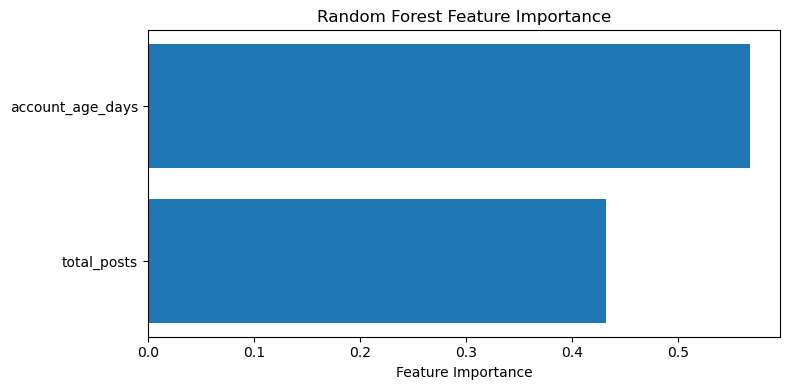

In [22]:
# Cell 11: Model evaluation
print("Model Evaluation")
print("=" * 40)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()